# Laboratory 2: Classifying Images with a Vision Transformer (ViT)

This laboratory covers:

* Dividing an image into patches of tokens
* Training a Transformer to predict the next image token
* Classifying CIFAR-10 images using a trained Vision Transformer (ViT)
* Visualizing how a trained ViT pays attention to different parts of an image

In Transformer-based text-to-image generation, a crucial step involves converting an image into a sequence of tokens, similar to how text is transformed into a sequence of words. This process is carried out using a Vision Transformer (ViT), a groundbreaking approach that has revolutionized the application of Transformer models to computer vision tasks. The concept of the ViT was introduced in 2020 by a team of researchers at Google in their seminal paper, *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale*.  Their work demonstrated how Transformers, originally designed for natural language processing (NLP), could achieve state-of-the-art performance across a wide range of computer vision challenges.

In this laboratory, we will explore the foundational concepts and practical implementation of the ViT. We will start by learning how to build a ViT model from scratch and use it to tackle image classification tasks on the popular CIFAR-10 dataset. The process begins with dividing an image into an $8\times 8$ grid, producing $64$ patches where each patch acts as a token in the sequence. By representing the image as a series of tokens, the ViT enables the application of Transformers (designed for sequential data) to visual information.

Next, we will embark on the construction of the Transformer architecture itself, focusing on key components such as the self-attention mechanism and the feed-forward network. The self-attention mechanism allows the model to learn relationships between different patches in the image, capturing both local and global dependencies. This capability is instrumental in enabling the model to interpret and classify images with high accuracy.

Through hands-on implementation, we will train our ViT model on the CIFAR-10 dataset, optimizing it to distinguish between ten different classes of images. After training, we will put our model to the test, using it to classify unseen images with relatively high accuracy. To deepen our understanding, we will also visualize the attention maps produced by the model, revealing how it focuses on specific parts of an image during classification.

By the end of this laboratory, we will not only have a working ViT but also a solid understanding of how Transformers can be adapted for computer vision tasks, empowering us to extend these concepts to more advanced applications in text-to-image generation and beyond.

# 1. The CIFAR-10 Dataset
We will use the CIFAR-10 dataset to train the ViT in this laboratory. CIFAR-10 (CIFAR
stands for Canadian Institute for Advanced Research) is a popular dataset for training
machine learning, especially computer vision algorithms. The dataset consists of $10$
different classes of color images.

In this section, we will download the dataset, split it into a train and test set, and place
them in batches for training later. We will also visualize some sample images to see what
the images in this dataset look like.

## 1.1. Downloading and Visualizing CIFAR-10 Images
We will use the `datasets` package in the `torchvision` library to download the CIFAR-10 dataset directly. We first download the training set as follows:

In [ ]:
import torchvision

trainset=torchvision.datasets.CIFAR10(root=r'.',
                          train=True, download=True)

100%|██████████| 170M/170M [00:06<00:00, 26.7MB/s]


Each image in the CIFAR-10 dataset is labeled with a class number from $0$ to $9$. To convert these
numbers into meaningful object names, we define a list as follows:

In [ ]:
# Names of the ten types of objects
names = ['plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck']

This means an image with a label of $0$ is a plane, and a label of $1$ indicates the image is a bird, and so on.

Next, we can visualize the first $18$ images in the training set as follows:

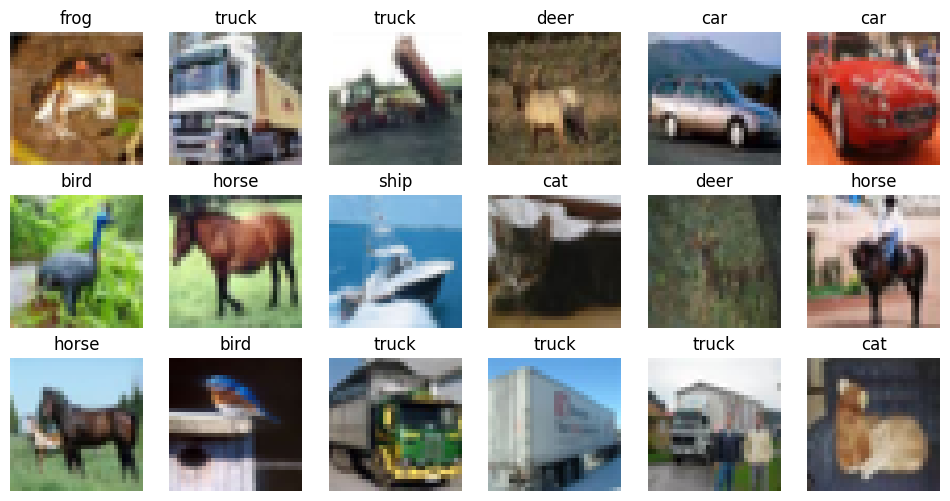

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 3 by 6 grid of images
plt.figure(figsize=(12,6),dpi=100)
for i in range(3):
    for j in range(6):
        plt.subplot(3, 6, 6*i+j+1)
        plt.imshow(trainset[6*i+j][0])
        plt.axis('off')
        plt.title(names[trainset[6*i+j][1]], fontsize=12)
plt.subplots_adjust(hspace=0.20)
plt.show()

We plot the $18$ images in a $3$ by $6$ grid. The `axis('off')` option in the `matplotlib` library allows us to turn off the axis so we see only the pictures. We place the name of each picture as the title of the picture, so that we see it on top of each
image. For example, the top left image is a frog while the bottom right image is a cat.

We also download the test set for out-of-the-sample testing to make sure that our trained model is not overfitted. This can be done as follows:

In [ ]:
testset=torchvision.datasets.CIFAR10(root=r'.',
                          train=False, download=True)

By using the `train=False` argument, we instruct the `torchvision` library to download the test subset instead of the train subset of the CIFAR-10 dataset.

## 1.2. Preparing Datasets for Training and Testing
The datasets we have downloaded are Python objects. We will transform them into PyTorch tensors so that we can feed them into the ViT later to train the model. We first transforms the training set as follows:

In [ ]:
import torchvision.transforms as transforms

trainset.transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Resize((32, 32),antialias=True),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomResizedCrop((32, 32), scale=(0.8, 1.0),
                 ratio=(0.75, 1.3333333333333333),
                 interpolation=2,antialias=True),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

Before the transformation, the image data are integers ranging from $0$ to $255$. We convert them to PyTorch float tensors with values between $-1$ to $1$. We also perform a
couple of image augmentations such as random horizontal flips and random resize
crops. These augmentations increase the variety of images in the training data without
extra data, reducing the risk of overfitting. Next, we place the training data in batches for training:

In [ ]:
import torch

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32,
                                            shuffle=True)

We apply similar transformation on the test set and place them in batches as well:

In [ ]:
testset.transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Resize((32, 32),antialias=True),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
testloader = torch.utils.data.DataLoader(testset, batch_size=32,
                                        shuffle=False)

We now have the training and testing datasets ready. In the next section, we will build a ViT to classify these images.

# 2.	Building a Vision Transformer (ViT) from Scratch

To convert an image into a sequence, we will first divide an image (with a size of $3 \times 32
\times 32$) into an $8 \times 8$ grid, hence $64$ different patches. Each patch therefore has a size of
$(3, 4, 4)$ because $32 ÷ 8 = 4$. We will use a convolutional layer to convert each patch into a vector with $48$ values. These vectors are considered tokens. By doing this, we convert an
image into a sequence of $64$ tokens.

ViT uses the scaled dot product attention (SDPA) mechanism to capture the relationships
among different tokens, which represent different patches in the image. In
this section, we will explain how to code the SDPA attention mechanism and construct a
ViT from scratch to classify images.

## 2.1.	Dividing Images into Patches
We first define a few hyperparameters that we will use in our ViT. *Hyperparameters* are
parameters that control the learning process in machine learning models. Their values
are set before the learning process starts and won’t change due to training. In contrast, parameters are randomly initialized when we create the model, and their
values are adjusted during training. Specifically, we treat all hyperparameters in our
model as class variables in the following `Config` class.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

Training neural networks can be time-consuming, especially when the network is deep with many layers and is trained on large amounts of data. PyTorch provides GPU acceleration since it supports CUDA, which enables it to efficiently perform computations on GPU, significantly speeding up the training and inference processes. PyTorch automatically detects if a CUDA-enabled GPU is installed on our machine and decides if GPU acceleration should be used in training.

The above line of code automatically checks if a CUDA-enabled GPU is available for accelerated training. If yes, the program will use GPU to train the model. Otherwise, the program will default the training device to the CPU.

In [ ]:
class Config: #Define the Config class
    patch_size=4 #Each image patch has a height and width of 4 pixels
    hidden_size=48 #Each image patch is converted to a 48-value tensor
    num_hidden_layers=4
    num_attention_heads=4
    intermediate_size= 4 * 48
    image_size=32
    num_classes=10
    num_channels=3
config=Config() #Instantiates the Config class and names it config

The class variable `patch_size=4` means each patch of image has a height and width of
$4$ pixels. Because our training images are $32 \times 32$ pixels, this means we divided each
image into an $8 \times 8$ grid with $64$ patches. The class variable `hidden_size=48` means each
patch is converted into a $48$-value vector. We will use multi-head attention to capture
different aspects of relationships among tokens in the image, so we set `num_attention_heads=4`. This means we use four attention heads instead of just one when calculating
attention. We will explain other hyperparameters as we go along.

To divide an image into $64$ patches, we define a `PatchEmbeddings` class as follows:

In [ ]:
from torch import nn

class PatchEmbeddings(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.projection = nn.Conv2d(config.num_channels, #Passes the image through a Conv2d layer
                                    config.hidden_size,
                                    kernel_size=config.patch_size, #Sets the kernel size to 4, which equals the patch size
                                    stride=config.patch_size) #Sets the stride size to 4, which equals the patch size
    def forward(self, x):
        x = self.projection(x)
        x = x.flatten(2).transpose(1, 2) #Rearranges the output so it has a dimension of 64 × 48
        return x

The `PatchEmbeddings` class takes a batch of images of size $3 \times 32 \times 32$ and divides each
image into an $8 \times 8$ grid (hence, $64$ patches). The class then uses the `Conv2d` layer to
convert each image patch into a $48$-value vector. We set both the kernel size and stride
size to $4$, so the kernel slides on each patch just once. This ensures that each image
patch is represented by a tensor with a dimension equal to $48$ (the number of output
channels in the `Conv2d` layer). As a result, a $3 \times 32 \times 32$ image becomes a tensor of $48
\times 8 \times 8$ after passing through the `Conv2d` layer. We then rearrange the output so each
image has a dimension of $64 \times 48$, meaning each of the $64$ patches is represented by a $48$-value vector.

To have a better understanding of how the `PatchEmbeddings` class works, we will create a hypothetical image and pass it through the class, and print out the shape of the output, as follows:

In [ ]:
patchembed=PatchEmbeddings(config)
img=torch.randn((1,3,32,32)) #Creates a hypothetical image
out=patchembed(img) # Passes the image through the PatchEmbeddings class
print(out.shape) #Shows the shape of the output

torch.Size([1, 64, 48])


We use `torch.randn()` to generate a tensor with a size of $(1, 3, 32, 32)$: there’s one
image in the batch with a shape of $3 \times 32 \times 32$. We then pass the image through the
`PatchEmbeddings` class.

The output has a shape of $(1, 64, 48)$, meaning there is one image in the batch divided
into $64$ patches, and each patch is represented by a $48$-value vector.

## 2.2.	Modeling the Positions of Different Patches in an Image
We have transformed each image into $64$ patches, effectively converting the images into
sequential data. Sequential data refers to datasets where the order of elements is crucial,
as the relative positioning of elements often carries critical information necessary
for understanding the data. The arrangement of patches within an image is significant
because swapping the positions of two patches results in a fundamentally different
image.

To add the position of each patch within an image to the final output, we define
an `Embeddings` class as follows:

In [ ]:
class Embeddings(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.patch_embeddings = PatchEmbeddings(config)
        self.cls_token = nn.Parameter(torch.randn(1, 1, #Adds the CLS token to the beginning of the sequence
                                      config.hidden_size))
        num_patches = (config.image_size // config.patch_size) ** 2
        self.position_embeddings = \
        nn.Parameter(torch.randn(1,num_patches+1,config.hidden_size)) #Uses learned positional encoding, with a dimension of (65, 48)
    def forward(self, x):
        x = self.patch_embeddings(x) #Passes the image through the PatchEmbeddings class
        batch_size, _, _ = x.size()
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1) #Embeds the image, with a dimension of (65, 48)
        x = x + self.position_embeddings #Adds positional encoding to the image embedding
        return x

In the `Embeddings` class, we first pass an image through the `PatchEmbeddings` class
so that the image is represented by $64$ image tokens. We then add the `CLS` (classification)
token to the beginning of the sequence. The `CLS` token is also a $48$-value vector
that will be used in the classification layer in our ViT to classify the image. The `CLS`
token isn’t associated with any specific part of the image but is used to aggregate information
across the entire image for the purpose of classification. This approach allows
ViT to use the strength of Transformer models for image analysis tasks.

Therefore, the image is now represented by $64 + 1 = 65$ tokens. To model the positions
of these tokens, we create a positional encoding for the sequence, with a size of
$65 \times 48$, the same as the size of token embeddings of the image. That is, the first position
is represented by a $48$-value vector, so is the second position, and so on. These $65$
positional vectors are learned from the training data. Finally, the positional encoding is
added to the token embedding and used as the output of the above `Embeddings` class.

We again use a hypothetical image and pass it through the `Embeddings` class to show how positional encoding works:

In [ ]:
embed=Embeddings(config)
img=torch.randn((1,3,32,32)) #Creates a hypothetical image
out=embed(img) #Passes the image through the class
print(out.shape) #Prints out the shape of the final output, which is the sum of token embedding and positional encoding
print(embed.position_embeddings.shape) #Prints out the shape of the positional encoding only

torch.Size([1, 65, 48])
torch.Size([1, 65, 48])


Both the output from the `Embeddings` class and the positional encoding has a shape of $(1, 65, 48)$.

## 2.3.	Using the Multi-Head Self-Attention Mechanism

As we explained in Laboratory 1, the SDPA uses query, key, and value to calculate the relationships
among elements in a sequence. It assigns scores to show how an element in a
sequence is related to all other elements. In addition, instead of using one set of query,
key, and value vectors, the Transformer model uses multi-head attention.

In our example, the embedding dimension is $48$ (meaning each token is represented
by a $48$-value vector), and we will split the $48$-dimensional query, key, and value vectors
into four heads. Each head has a set of query, key, and value vectors with dimensions of
$12$ ($48 ÷ 4 = 12$). Each head pays attention to different parts or aspects of the input (e.g.,
texture or edges), enabling the model to capture a broader range of information and
form a more detailed and contextual understanding of the image.

To implement this, we define the `AttentionHead` class as follows:

In [ ]:
class AttentionHead(nn.Module):
    def __init__(self, hidden_size, attention_head_size, bias=True):
        super().__init__()
        self.hidden_size = hidden_size
        self.attention_head_size = attention_head_size
        self.query = nn.Linear(hidden_size, attention_head_size, bias=bias)
        self.key = nn.Linear(hidden_size, attention_head_size, bias=bias)
        self.value = nn.Linear(hidden_size, attention_head_size, bias=bias)
    def forward(self, x):
        query = self.query(x)
        key = self.key(x)
        value = self.value(x) #Calculates query, key, and value vectors
        attention_scores = torch.matmul(query, key.transpose(-1, -2))
        attention_scores = attention_scores / math.sqrt(\
                self.attention_head_size)
        attention_probs = nn.functional.softmax(attention_scores, dim=-1) #Calculates attention weights
        attention_output = torch.matmul(attention_probs, value) #Final attention is the product of attention weights and the value vector
        return (attention_output, attention_probs)

The `AttentionHead` class takes a sequence $X$ as the input. It passes the input embedding
$X$ through three linear layers to obtain query, key, and value vectors. The corresponding
weights for the three linear layers are $W^Q$, $W^K$, and $W^V$, each having
a dimension of $12 \times 12$. These weights are learned from data during the training
phase. Thus, we calculate query $Q$, key $K$, and value $V$ as $Q = X * W^Q$, $K = X * W^K$, and $V
= X * W^V$.

We assess the similarities between the  query and key vectors using the SDPA approach. SDPA involves calculating the dot product of the query ($Q$) and key ($K$) vectors. A high dot product indicates a strong similarity between the two vectors, and vice versa. The dot product is scaled by the square root of $d_k$ (the dimension of the key vector $K$, which in our case is $12$ in each head) to obtain the scaled attention scores. The next step is to apply the softmax function to these attention scores, converting them into attention weights. This ensures that the total attention a token gives to all tokens in the sequence sums to $100\%$. The final attention is then calculated as the dot product of these attention weights and the value vector $V$.

The `MultiHeadAttention` class calculates multi-head attention as follows:

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.hidden_size = config.hidden_size
        self.num_attention_heads = config.num_attention_heads
        self.attention_head_size = \
        self.hidden_size // self.num_attention_heads
        self.all_head_size = \
        self.num_attention_heads * self.attention_head_size
        self.heads = nn.ModuleList([])
        for _ in range(self.num_attention_heads):
            head = AttentionHead(
                self.hidden_size,
                self.attention_head_size)
            self.heads.append(head)
        self.output_projection = nn.Linear(self.all_head_size,\
                                           self.hidden_size)
    def forward(self, x, output_attentions=False):
        attention_outputs = [head(x) for head in self.heads]
        attention_output = torch.cat([attention_output for attention_output,
                                      _ in attention_outputs], dim=-1)
        attention_output = self.output_projection(attention_output)
        if not output_attentions:
            return (attention_output, None)
        else:
            attention_probs = torch.stack([attention_probs for _,
                           attention_probs in attention_outputs], dim=1)
            return (attention_output, attention_probs)

The `MultiHeadAttention` class first creates multiple heads. It then passes the input sequence $X$ through each head and calculates the attention by using the `AttentionHead` class we defined earlier. It then concatenates the attention vectors in the four heads into one large attention vector.  

## 2.4.	Building an Encoder-Only Transformer
To create an encoder-only Transformer, we stack $N=4$ identical encoder layers together to increase representation capacity and enable hierarchical feature extraction. Each encoder layer is composed of two distinct sublayers: one is a multi-head self-attention layer, as defined in the `MultiHeadAttention` class, and the other is a straightforward, position-wise, fully connected feed-forward network, as defined in the `MLP` class, as follows:

In [ ]:
class GELU(nn.Module):
    def forward(self, input):
        return 0.5 * input * (1.0 + torch.tanh(math.sqrt(2.0 / math.pi) *\
                           (input + 0.044715 * torch.pow(input, 3.0))))

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.dense_1 = nn.Linear(config.hidden_size, #The first linear layer, with 48 input channels and 4 × 48 = 192 output channels
                                 config.intermediate_size)
        self.activation = GELU() #With GELU activation
        self.dense_2 = nn.Linear(config.intermediate_size,
                                 config.hidden_size) #The second linear layer, with 192 input channels and 48 output channels
    def forward(self, x):
        x = self.dense_1(x)
        x = self.activation(x)
        x = self.dense_2(x)
        return x

The `MLP` class is defined with two key parameters: `intermediate_size`, the dimensionality
of the feed-forward layer, and `hidden_size`, representing the model’s dimension
size. Typically, `intermediate_size` is chosen to be four times the size of `hidden_size`.
In our example, `hidden_size` is $48$, so we set `intermediate_size` to $4 \times 48 = 192$. This
practice is a standard approach in Transformer architectures. It enhances the network’s
ability to capture and learn complex features in the training dataset.

The input to the `MLP` class first goes through a linear layer with $48$ input channels
and $192$ output channels. The output then goes through the Gaussian error linear unit
(GELU) activation. The most commonly used activation function, rectified linear unit
(ReLU), isn’t differentiable everywhere. The GELU activation function, in contrast, is
differentiable everywhere and provides a better learning process, so we use the GELU
activation here. The last layer in the `MLP` class is a linear layer with $192$ input channels
and $48$ output channels. This way, the output has the same dimension as the input to
the `MLP` class. Next, we create an encoder block using the following `Block` class:

In [ ]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attention = MultiHeadAttention(config)
        self.layernorm_1 = nn.LayerNorm(config.hidden_size)
        self.mlp = MLP(config)
        self.layernorm_2 = nn.LayerNorm(config.hidden_size)
    def forward(self, x, output_attentions=False):
        attention_output, attention_probs = \
        self.attention(self.layernorm_1(x), #The input first goes through layer normalization and then the multi-head attention layer
                       output_attentions=output_attentions)
        x = x + attention_output #Applies residual connections
        mlp_output = self.mlp(self.layernorm_2(x)) #Goes through layer normalization again and then the feed-forward network
        x = x + mlp_output #Applies residual connections again
        if not output_attentions:
            return (x, None)
        else:
            return (x, attention_probs)

Each encoder block contains two sublayers: a multi-head self-attention layer and a
feed-forward network. Additionally, both of these sublayers incorporate layer normalization
and residual connections. A residual connection involves passing the input
through a sequence of transformations and then adding the input back to these transformations’
output. The method of residual connection is employed to combat the
issue of vanishing gradients, which is a common challenge in very deep networks. Layer
normalization standardizes the observations in a layer to have a zero mean and a unit
standard deviation.

We stack four such encoder blocks together to form an encoder-only Transformer, as illustrated by the following `Encoder` class:

In [ ]:
class Encoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.blocks = nn.ModuleList([])
        for _ in range(config.num_hidden_layers):
            block = Block(config)
            self.blocks.append(block) #Stacks four encoder layers together
    def forward(self, x, output_attentions=False):
        all_attentions = []
        for block in self.blocks:
            x, attention_probs = block(x,
               output_attentions=output_attentions) #The input goes through the four encoder layers sequentially
            if output_attentions:
                all_attentions.append(attention_probs)
        if not output_attentions:
            return (x, None)
        else:
            return (x, all_attentions) #If required, returns attention weights as well

There are four encoder blocks in the encoder-only Transformer. The output from the
first block is used as the input to the second block. The output from the second block is
used as the input to the third block, and so on. The `output_attentions` argument can
be set as either `True` or `False`. If it’s set as `True`, both the final output and all the intermediate
attention weights are returned. Otherwise, only the final output is returned.

## 2.5.	Using the Vision Transformer to Create a Classifier
Typically, a Transformer can be used for various downstream tasks such as text generation, classification, or summarization. In our setting, the goal is to use the Vision Transformer to classify images in the CIFAR-10 dataset. We therefore create a classifier based on the Vision Transformer we just built through the `ViTForClassification` class:

In [ ]:
class ViTForClassfication(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.image_size = config.image_size
        self.hidden_size = config.hidden_size
        self.num_classes = config.num_classes
        self.embedding = Embeddings(config)
        self.encoder = Encoder(config)
        self.classifier = nn.Linear(self.hidden_size,
                                    self.num_classes) #Attaches a head at the end of the model to create a classifier with 10 output classes
        self.apply(self._init_weights)
    def forward(self, x, output_attentions=False):
        embedding_output = self.embedding(x) #Input images first go through the Embedding class to generate input embeddings
        encoder_output, all_attentions = self.encoder(\
          embedding_output,output_attentions=output_attentions) #The input embeddings go through the ViT to create encoder output
        logits = self.classifier(encoder_output[:, 0, :]) #The encoder output goes through the classifier head to obtain the logits corresponding to the 10 classes of labels
        if not output_attentions:
            return (logits, None)
        else:
            return (logits, all_attentions)
    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Conv2d)):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)
        elif isinstance(module, Embeddings):
            module.position_embeddings.data = nn.init.trunc_normal_(
                module.position_embeddings.data.to(torch.float32),
                mean=0.0,std=0.02,).to(module.position_embeddings.dtype)
            module.cls_token.data = nn.init.trunc_normal_(
                module.cls_token.data.to(torch.float32),
                mean=0.0,std=0.02,).to(module.cls_token.dtype)

The `ViTForClassification` class takes a batch of images as input and outputs the logits
over the $10$ classes of objects. Later, we will apply the softmax function on these logits
to obtain the probability distributions of the images over the $10$ classes.

To achieve this, the `ViTForClassification` class first passes the images through
the `Embeddings` class defined earlier to obtain the input embedding, which is the sum
of token embedding and positional encoding. The input embeddings are then passed
through the encoder-only ViT. The output from the ViT is passed through a classifier
head, with $10$ output neurons, corresponding to the $10$ classes of labels.

Instead of using all outputs from the ViT to classify images, we use only the output
associated with the `CLS` token. As explained earlier, the `CLS` token is not associated with
any specific part of the image but is used to aggregate information across the entire
image for the purpose of classification.

# 3.	Training and Using the Vision Transformer to Classify Images
Our constructed classifier can be trained to predict which class an image belongs to
in the CIFAR-10 dataset. In this section, we will detail the process of selecting an appropriate
loss function and optimizer. We will train the ViT using batches of data prepared earlier in this laboratory. After the model is trained, we will use it to classify images in the test set (i.e., unseen images), in the next section.

## 3.1. Choosing the Optimizer and the Loss Function
We first instantiate the `ViTForClassfication` class to create an image classifier, as follows:

In [ ]:
model = ViTForClassfication(config).to(device)

We will use the AdamW optimizer, a variant of the Adam optimizer that has been widely used in machine learning. The AdamW optimizer, first proposed by I. Loshchilov and F. Hutter, decouples weight decay (a form of regularization) from the optimization steps (I. Loshchilov and F. Hutter, 2017, *Decoupled Weight Decay Regularization*). Instead of applying weight decay directly to the gradients, AdamW applies weight decay directly to the parameters (weights) after the optimization step. This modification helps achieve better generalization performance by preventing the decay rate from being adapted along with the learning rates:

In [ ]:
from torch import nn, optim

optimizer = optim.AdamW(model.parameters(),
                lr=0.01, weight_decay=1e-2)

Because this is a multicategory classification problem, we will use the categorical cross-entropy
loss function, as follows:

In [ ]:
loss_fn = nn.CrossEntropyLoss()

We will use PyTorch’s automatic mixed-precision package `torch.amp` to speed up training.
The default data type in PyTorch tensors is `float32`, a $32$-bit floating-point number,
which takes up twice as much memory as a $16$-bit floating number, `float16`. Operations
on the former are slower than those on the latter. There is a tradeoff between precision
and computational costs. Which data type to use depends on the task at hand. The
package `torch.amp` provides an automatic mixed precision, where some operations use
`float32` and others `float16`. Mixed precision tries to match each operation to its appropriate
data type to speed up training. We therefore instantiate a `GradScaler` class as
follows:

In [ ]:
scaler = torch.amp.GradScaler()

The use of PyTorch’s automatic mixed-precision package may reduce the training time.

## 3.2. Training the ViT for Image Classification
When we build and train a deep neural network, there are many hyperparameters
that we can choose (e.g., the learning rate and the number of epochs to train). These
hyperparameters affect the performance of the model. To find the best hyperparameters,
we can use a validation set to gauge the performance of the model with different
hyperparameters.

To illustrate, we will use the test dataset to help determine the optimal number of training
epochs. It is important to make this decision using data that the model has not seen
during training, rather than relying solely on the training set. If we use only the training
set to choose how many epochs to train for, we risk overfitting: the model may learn to
perform very well on the training data but fail to generalize to new, unseen examples.
This happens because training for too many epochs can cause the model to memorize
patterns specific to the training data, rather than capturing generalizable features. By
monitoring performance on the test set, we can identify the point where the model
achieves its best out-of-sample performance, helping to avoid overfitting.

For this purpose, we define an `EarlyStop` class and create an instance of the class as follows:

In [ ]:
class EarlyStop:
    def __init__(self, patience=3):
        self.patience = patience
        self.steps = 0
        self.min_loss = float('inf')
    def stop(self, loss):
        if loss < self.min_loss: #If the loss in the test set is smaller than the previously achieved minimum, keep training
            self.min_loss = loss
            self.steps = 0
            to_save = True
        elif loss >= self.min_loss: #If the loss in the test set is larger than the previously achieved minimum, add 1 to the counter
            self.steps += 1
            to_save = False
        if self.steps >= self.patience: #If the performance doesn’t improve in three consecutive epochs, stop training
            to_stop = True
        else:
            to_stop = False
        return to_save, to_stop

stopper=EarlyStop() #Instantiates the EarlyStop class

The `EarlyStop` class keeps track of the performance of the model, as measured by
the loss in the test set. If the loss is smaller than the previously achieved minimum,
we keep training the model. If the loss is larger than the previously achieved minimum,
the model performance did not improve in this epoch. We therefore add `1` to
the counter `steps`. If the model performance did not improve for three consecutive
epochs, we stop the training loop. Note that we can determine when to stop training
by adjusting the `patience` parameter. We set the value of `patience` to `3` in the preceding
example. If we set `patience` to, say, `10`, then we will stop training only if the model fails
to improve in $10$ consecutive epochs.

We also define a `train_batch()` function to train the model with a batch of the training
data:

In [ ]:
def train_batch(batch):
    batch = [t.to(device) for t in batch] #Moves training data to CUDA-enabled GPU, if available
    images, labels = batch
    with torch.amp.autocast(device):
        loss = loss_fn(model(images)[0], labels) #Trains the model with the batch of training data
    optimizer.zero_grad()
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    return loss.item()*len(images)/len(trainloader.dataset) #Returns the loss in the batch

The function first moves the batch of training data to the CUDA-enabled GPU, if available.
It then trains the model using PyTorch’s automatic mixed-precision package.
Finally, the function returns the training loss in the batch. Note that we have scaled the loss
by the ratio of the number of images in the batch and the total number of images in
the training set. The scaling ensures that later, when we report training loss, it measures
the loss in each image, on average.

Next, we train the model for a maximum of $100$ epochs. We will use the `EarlyStop`
class to stop training if the model stops improving on the test set for three consecutive
epochs. Further, the best model parameters are saved if an epoch achieves the best performance
on the test set.

In [ ]:
#19min
from tqdm import tqdm
import os
import math

os.makedirs("files", exist_ok=True)
for i in range(100):
    print(f'Epoch {i+1}')
    model.train()
    trainL, testL = 0, 0
    for batch in tqdm(trainloader): #Trains the model for one epoch
        loss=train_batch(batch)
        trainL+=loss
    model.eval()
    with torch.no_grad():
        for batch in testloader: #Tests the model in the test set
            batch = [t.to(device) for t in batch]
            images, labels = batch
            logits, _ = model(images)
            loss = loss_fn(logits, labels)
            testL+=loss.item()*len(images)/len(testloader.dataset)
    print(f'Train and test losses: {trainL:.4f}, {testL:.4f}')
    to_save, to_stop = stopper.stop(testL)
    if to_save==True: #If the model performance improves in this epoch, save the model parameters
        torch.save(model.state_dict(),"files/ViT.pth")
    if to_stop==True: #If the model fails to improve in three consecutive epochs, stop training
        break

Epoch 1


100%|██████████| 1563/1563 [01:27<00:00, 17.77it/s]


Train and test losses: 1.8351, 1.5577
Epoch 2


100%|██████████| 1563/1563 [01:25<00:00, 18.18it/s]


Train and test losses: 1.5357, 1.4525
Epoch 3


...

Train and test losses: 1.2612, 1.2245
Epoch 12


100%|██████████| 1563/1563 [01:25<00:00, 18.38it/s]


Train and test losses: 1.2518, 1.2406
Epoch 13


100%|██████████| 1563/1563 [01:24<00:00, 18.57it/s]


Train and test losses: 1.2344, 1.3004


The training stopped after $13$ epochs because the model performance did not improve
after $10$ epochs. The best model parameters, which are those after $10$ epochs of training,
are saved in the file `ViT.pth` in the `files` folder.

## 3.3. Classifying Images Using the Trained Vision Transformer
To use the trained ViT to classify images, we obtain a batch of $32$ images from the test
dataset. We make predictions on the images and obtain attention maps for each image.

In [ ]:
import math
import torch.nn.functional as F

model.load_state_dict(torch.load('files/ViT.pth'))
model.eval()
with torch.no_grad():
    batch=next(iter(testloader)) #Obtains a batch of 32 images from the test dataset
    batch = [t.to(device) for t in batch]
    images, labels = batch
    logits, attention_maps = model(images, output_attentions=True) #Obtains logits and attention maps using the trained model
    predictions = torch.argmax(logits, dim=1) #Makes predictions based on the highest logits

print(predictions)
print([names[i] for i in predictions.tolist()]) #Prints out the names of the predicted labels

tensor([3, 8, 1, 8, 6, 3, 1, 6, 5, 1, 4, 1, 6, 5, 1, 8, 5, 7, 8, 6, 7, 0, 4, 1,
        4, 5, 7, 4, 1, 6, 6, 5], device='cuda:0')
['cat', 'ship', 'car', 'ship', 'frog', 'cat', 'car', 'frog', 'dog', 'car', 'deer', 'car', 'frog', 'dog', 'car', 'ship', 'dog', 'horse', 'ship', 'frog', 'horse', 'plane', 'deer', 'car', 'deer', 'dog', 'horse', 'deer', 'car', 'frog', 'frog', 'dog']


We first load the model with the trained weights. Next, we extract a batch of $32$ test
images and pass them through the model to obtain both the predicted logits and the
attention maps. Logits are the raw, unnormalized outputs produced for each class
before being transformed into probabilities via the softmax function. We then make
a prediction for each image based on the highest logit value, resulting in a list called
`predictions` that contains $32$ predicted numerical labels (each ranging from $0$ to $9$).
The corresponding label names are printed out as shown above.

The output shows that the first three numerical predictions are `8`, which corresponds
to the word label `'ship'`. The fourth numerical prediction is `0`, indicating `'plane'`, and
so on. We will evaluate the overall accuracy of these predictions later.

The `attention_maps` list contains four tensors, each representing the attention map
from a different encoder layer. Let’s explore these attention maps here:

In [ ]:
for attn in attention_maps:
    print(attn.shape) #The shape of the attention map in each encoder layer
block0_image0_head0=attention_maps[0][0,0,:,:] #The attention map for the first attention head in the first image in the first encoder layer
print(block0_image0_head0.shape)
probs_sum=torch.sum(block0_image0_head0,dim=1) #Adds up the value of attention across columns
print(probs_sum)

torch.Size([32, 4, 65, 65])
torch.Size([32, 4, 65, 65])
torch.Size([32, 4, 65, 65])
torch.Size([32, 4, 65, 65])
torch.Size([65, 65])
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000], device='cuda:0')


We begin by printing the shape of the attention map for each encoder layer. Next,
we focus on the attention map from the first attention head of the first image in the
first encoder layer, referred to as `block0_image0_head0`, which has a shape of $65 \times 65$.
Finally, we sum the values in each column and print the results, as shown above.

The results indicate that the attention map for each encoder layer has a shape of `[32, 4, 65, 65]`. This means that there are $32$ images in the batch, and for each image, the
attention map is generated for four different attention heads. Each head produces a $65 \times 65$ probability matrix, where each image is divided into $65$ tokens, the first being the
`CLS` token and the remaining $64$ corresponding to an $8 \times 8$ grid of patches. This matrix
shows the amount of attention each token allocates to every token in the sequence,
and each column sums to $1$, representing a complete ($100\%$) distribution of attention.
Next, we visualize the attention maps for each image.

attention map shape: torch.Size([32, 16, 65, 65])
attention map shape: torch.Size([32, 16, 64])
attention map shape: torch.Size([32, 64])
attention map shape: torch.Size([32, 8, 8])
attention map shape: torch.Size([32, 32, 32])


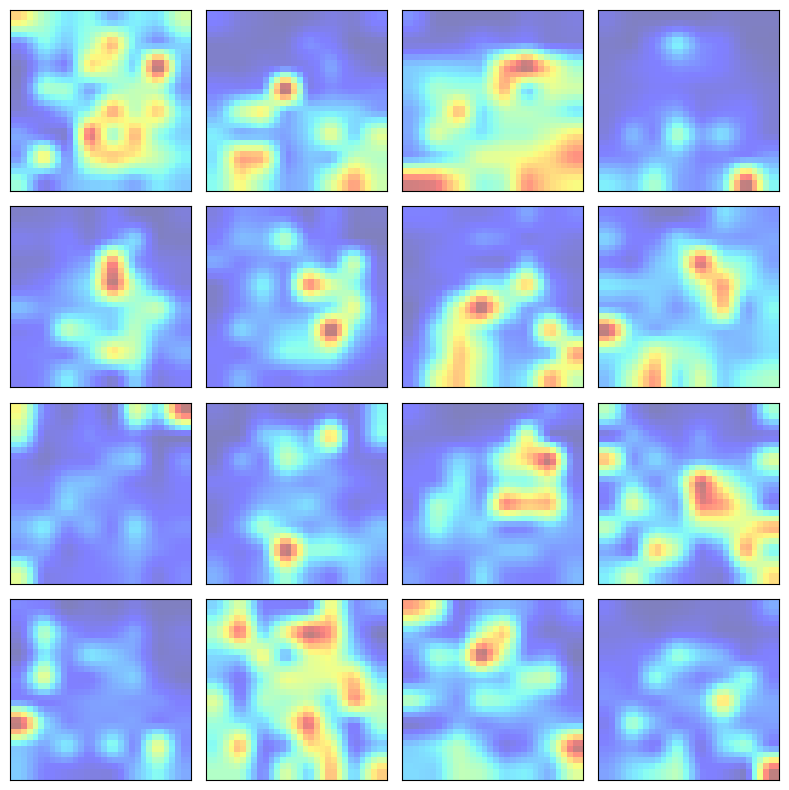

In [ ]:
with torch.no_grad():
    attention_maps = torch.cat(attention_maps, dim=1) #Concatenates the attention maps from the four encoder layers into one
    print(f"attention map shape: {attention_maps.shape}")
    attention_maps = attention_maps[:, :, 0, 1:] #Focuses on the attention between the CLP token and the 64 image tokens
    print(f"attention map shape: {attention_maps.shape}")
    attention_maps = attention_maps.mean(dim=1)
    print(f"attention map shape: {attention_maps.shape}")
    num_patches = attention_maps.size(-1)
    size = int(math.sqrt(num_patches))
    attention_maps = attention_maps.view(-1, size, size) #Takes the average and resizes the attention map into an 8 × 8 image
    print(f"attention map shape: {attention_maps.shape}")
    attention_maps = attention_maps.unsqueeze(1)
    attention_maps = F.interpolate(attention_maps, size=(32, 32),
                       mode='bilinear', align_corners=False)
    attention_maps = attention_maps.squeeze(1) #Upscales the attention map to a 32 × 32 image to match the original image size
    print(f"attention map shape: {attention_maps.shape}")

fig = plt.figure(figsize=(8, 8),dpi=100)
for i in range(16):
    ax = fig.add_subplot(4,4, i+1, xticks=[], yticks=[])
    ax.imshow(attention_maps[i].cpu(), alpha=0.5, cmap='jet')
plt.tight_layout()
plt.show() #Plots the attention map for each of the first 16 images in the batch

We start by concatenating the attention maps from all four encoder layers into a single
tensor with a shape of `[32, 16, 65, 65]`. This shape indicates that there are $32$ images in
the batch and $16$ attention maps per image (four heads from each of the four layers),
with each attention probability matrix being $65 \times 65$. Next, we extract the attention values
corresponding to the interaction between the `CLS` token and the $64$ image patches
from the $8 \times 8$ grid. This results in a tensor of shape `[32, 16, 64]`, where each of the $64$
values represents the attention the `CLS` token pays to each image patch. We then average
the $16$ values to reduce the size of the attention tensor to `[32, 64]`. For each image
in the batch, we reshape the $64$ attention values into an $8 \times 8$ image and upscale it to
a $32 \times 32$ image to match the original image’s size. The attention maps of the first $16$
images are shown above.

The figure above highlights certain regions in the image, but it can be difficult to tell exactly
which areas of the image are emphasized. To clarify this, we compare the attention map
with the original image by displaying them side by side. Additionally, we overlay both
the actual and predicted labels on the images, as shown below.

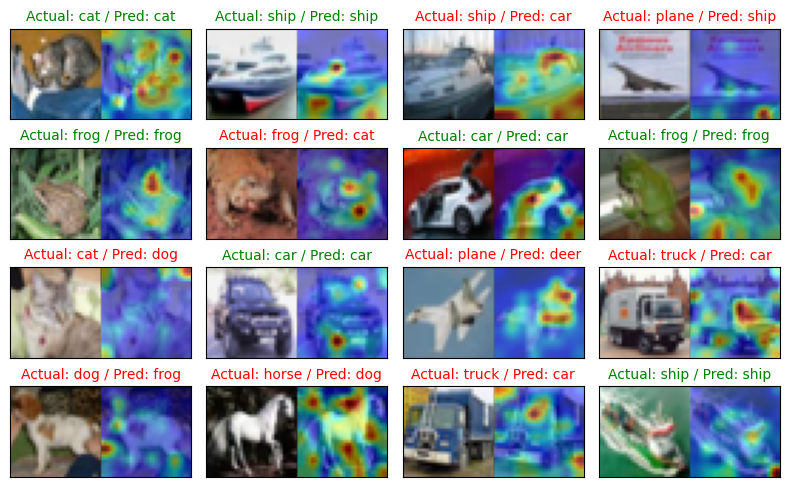

In [ ]:
fig = plt.figure(figsize=(8, 5),dpi=100)
mask = np.concatenate([np.ones((32, 32)), np.zeros((32, 32))],
                      axis=1)
for i in range(16):
    ax = fig.add_subplot(4,4, i+1, xticks=[], yticks=[])
    img = np.concatenate((images[i].cpu(), images[i].cpu()),
                         axis=-1)
    ax.imshow(img.transpose(1,2,0)/2+0.5) #Shows the original image
    extended_attention_map = np.concatenate((np.zeros((32, 32)),
                                     attention_maps[i].cpu()),
                                            axis=1)
    extended_attention_map = np.ma.masked_where(mask==1,
                                    extended_attention_map) #Adds the attention map to the right of the original image
    ax.imshow(extended_attention_map, alpha=0.5, cmap='jet')
    gt = names[labels[i]]
    pred = names[predictions[i]]
    ax.set_title(f"Actual: {gt} / Pred: {pred}",
                 color=("green" if gt==pred else "red"),
                fontsize=10) #Places both the original and the predicted labels on top of the image
plt.tight_layout()
plt.show()

In
each image pair, the left side displays the original test image, while the right side shows
the corresponding attention map generated by the trained ViT model during prediction.
The attention map is overlaid on the original image as its background, clearly
indicating which areas are emphasized.

Each subplot displays the actual and predicted labels as titles, green if the prediction is
correct and red otherwise.

Next, we calculate the overall prediction accuracy of the trained ViT in the test
dataset:

In [ ]:
model.eval()
acc = 0
with torch.no_grad():
    for batch in testloader: #Iterates through all batches in the test dataset
        batch = [t.to(device) for t in batch]
        images, labels = batch
        logits, _ = model(images)
        predictions = torch.argmax(logits, dim=1) #Makes predictions using the trained ViT classifier
        acc += torch.sum(predictions ==\
             labels).item()/ len(testloader.dataset)
print(f'the prediction accuracy is {acc:.4f}') #Prints out the overall accuracy of the predictions

the prediction accuracy is 0.5627


The accuracy is $\sim 56\%$. Given that the $10$ classes of images are evenly distributed in
the test dataset, a random guess will have an accuracy of about $10\%$. Therefore, the
model’s prediction accuracy of $\sim 56\%$ indicates that the model does capture the
defining features in each class of images and performs well.

# Exercises



1.   Plot the first $18$ images in the test dataset in a $3 \times 6$ grid. Use the `axis('off')`
option in the `matplotlib` library to turn off the axis so we see only the images, not
the x- or y-axis values. Place the name of each picture as the title so that we see a
name on top of each image.


2.   We can access the value of the class variables by using the dot notation. For example,
`print(config.hidden_size)` leads to an output of $48$. What is the output for
`print(config.num_classes)`?



3.   Use `torch.randn()` to generate a tensor with a size of $(5, 3, 32, 32)$. Pass the tensor
through the `PatchEmbeddings` class. Print out the shape of the output. What is the
meaning of each number in the shape of the output?